In [35]:
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Load Data

In [36]:
# load in cleaned dataset
train = pd.read_csv('data/train_cleaned.csv')
test = pd.read_csv('data/test_cleaned.csv')
y = train[["SalePrice"]]
test_ids = test['Id'] # for submit to kaggle

train.drop(columns=["Id","SalePrice"],inplace=True)
test.drop(columns=["Id"],inplace=True)

# train test split
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Selection

<Axes: >

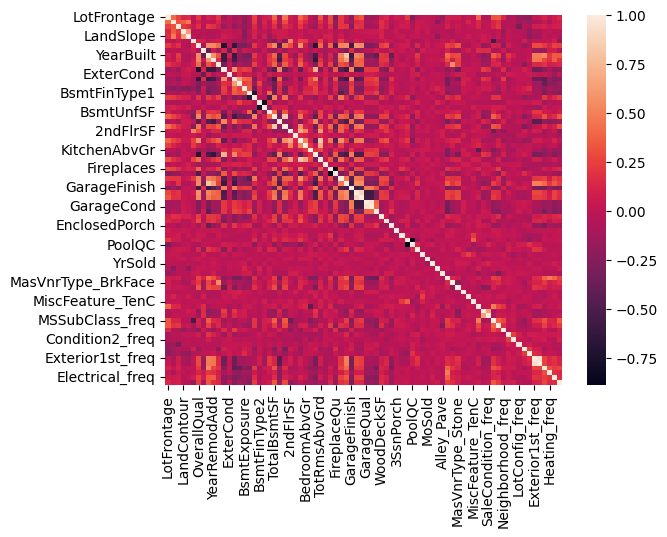

In [67]:
corr = X_train.corr()
sns.heatmap(corr)

In [75]:
# stepwise AIC feature selection (compare to BIC, it can allow more features)
def stepwise_aic(X, y, initial_features=None):
    included = list(initial_features) if initial_features else []

    def aic_of(features):
        if not features:
            return np.inf
        return sm.OLS(y, sm.add_constant(X[features])).fit().aic

    current_aic = aic_of(included)

    while True:
        changed = False

        # forward
        excluded = list(set(X.columns) - set(included))
        add_candidates = {col: aic_of(included + [col]) for col in excluded}
        if add_candidates:
            best_add_feature = min(add_candidates, key=add_candidates.get)
            best_add_aic = add_candidates[best_add_feature]
        else:
            best_add_feature, best_add_aic = None, np.inf

        # backward
        remove_candidates = {col: aic_of([c for c in included if c != col]) for col in included}
        if remove_candidates:
            best_remove_feature = min(remove_candidates, key=remove_candidates.get)
            best_remove_aic = remove_candidates[best_remove_feature]
        else:
            best_remove_feature, best_remove_aic = None, np.inf

        # print best move
        best_move_aic = min(best_add_aic, best_remove_aic, current_aic)

        if best_move_aic < current_aic:
            if best_add_aic < best_remove_aic:
                included.append(best_add_feature)
                current_aic = best_add_aic
                changed = True
                print(f"Add    {best_add_feature:>20}, AIC = {best_add_aic:.2f}")
            else:
                included.remove(best_remove_feature)
                current_aic = best_remove_aic
                changed = True
                print(f"Remove {best_remove_feature:>20}, AIC = {best_remove_aic:.2f}")

        if not changed:
            print("AIC Done! #feature = ", len(included))
            break

    return included

In [76]:
included = stepwise_aic(X_train,y_train)

Add             OverallQual, AIC = 28488.02
Add               GrLivArea, AIC = 28192.60
Add              BsmtFinSF1, AIC = 28069.49
Add              GarageCars, AIC = 27960.48
Add               ExterQual, AIC = 27885.89
Add         MSSubClass_freq, AIC = 27826.35
Add            BsmtExposure, AIC = 27765.73
Add             KitchenQual, AIC = 27741.25
Add       Neighborhood_freq, AIC = 27714.19
Add             FireplaceQu, AIC = 27698.95
Add         Condition1_freq, AIC = 27683.66
Add              Functional, AIC = 27672.97
Add                 LotArea, AIC = 27663.90
Add              GarageCond, AIC = 27655.59
Add             OverallCond, AIC = 27646.99
Add        No. of bathrooms, AIC = 27637.58
Add          RoofStyle_freq, AIC = 27630.21
Add           BldgType_freq, AIC = 27622.58
Add                BsmtQual, AIC = 27616.52
Add                BsmtCond, AIC = 27606.83
Add              HouseStyle, AIC = 27600.09
Add              MasVnrArea, AIC = 27592.66
Add      MasVnrType_BrkFace, AIC

In [77]:
# using selected features
X_train_aic = X_train[included]
X_test_aic = X_test[included]
test_aic = test[included]

['GarageQual', 'TotRmsAbvGrd']


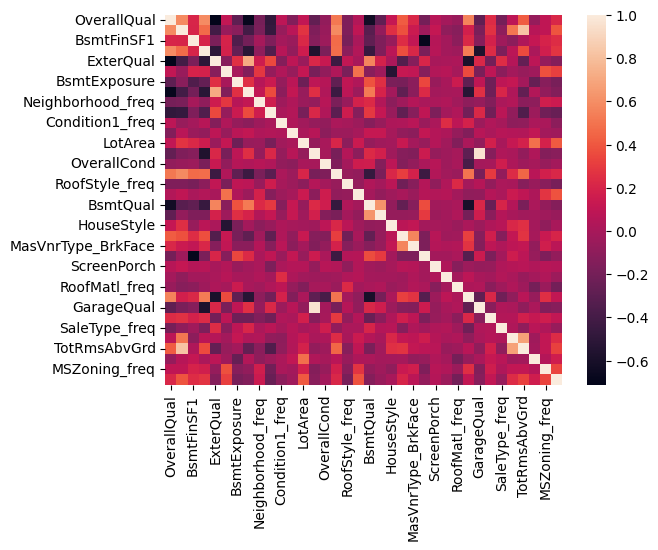

In [78]:
# this is for further removing the feature by correlation
corr = X_train_aic.corr()
sns.heatmap(corr)

# triangle matrix for delete
corr = X_train_aic.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# columns to drop
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print(to_drop)
X_train_aic2 = X_train_aic.drop(columns=to_drop)
X_test_aic2 = X_test_aic.drop(columns=to_drop)
test_aic2 = test_aic.drop(columns=to_drop)

### Train Model

In [50]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor().fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred)))
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.20549823318159235
R^2:  0.7220983943367307


In [66]:
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train_aic2, y_train)
y_pred = model.predict(X_test_aic2)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test_aic2,y_test))

0.1507807044775389
R^2:  0.8997858762741089


In [52]:
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train_aic, y_train)
y_pred = model.predict(X_test_aic)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test_aic,y_test))

0.1493038319394576
R^2:  0.8931635618209839


### Old Code

In [13]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.25584082730484886
R^2:  0.8463087351750634


In [ ]:
# # area is large, log to lower the numbers
# train['LotArea']=np.log(train['LotArea']+1)

from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.3141076552842453
R^2:  0.8436209489965238


In [14]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
reg = LinearRegression().fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.3141076552842453
R^2:  0.8436209489965238


In [13]:

from sklearn.tree import DecisionTreeRegressor
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
reg = DecisionTreeRegressor().fit(X_train,y_train)
y_pred = reg.predict(X_test)
np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred)))
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.22500147943748008
R^2:  0.7749060300771838


In [14]:
import xgboost as xgb

X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.13708934533545125
R^2:  0.9118821037842014


In [166]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
    min_child_weight=5,
    max_depth=5,
    reg_lambda=1,
    n_estimators=250, 
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.1301114725508227
R^2:  0.9184968046528881


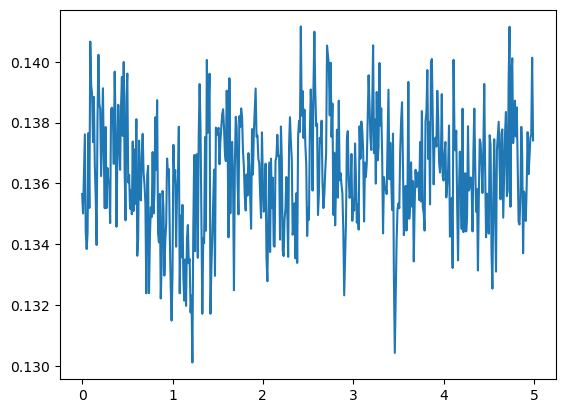

In [155]:
lambdas = []
errors = []
for i in range(500):
    model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
        min_child_weight=5,
        max_depth=5,
        reg_lambda=i/100,
        n_estimators=250, 
        random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    lambdas.append(i/100)
    errors.append(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))


In [167]:
errors.index(min(errors))
lambdas[errors.index(min(errors))]

1.22

In [176]:
estimators = []
errors = []
for i in range(200):
    model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
        min_child_weight=5,
        max_depth=5,
        reg_lambda=1.22,
        n_estimators=150+i, 
        random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    estimators.append(i)
    errors.append(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))


In [178]:
errors.index(min(errors))
estimators[errors.index(min(errors))]

5

In [179]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
    min_child_weight=5,
    max_depth=5,
    reg_lambda=1.22,
    n_estimators=155, 
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.12928888900843716
R^2:  0.9177386817717241


In [33]:
pd.Series(pred).to_csv("test1.csv")